# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [12]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import matplotlib.pyplot as plt

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [17]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked', dtype=int)

In [18]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

Es claro que son diferentes asi que asumiendo que se refiere a las caracteristicas de cada codificador

LabelEncoder :	Asigna un número entero a cada categoría pero introduce orden artificial es peligroso si las variables que no tienen un orden natural ya que puede implicar que un valor es menor que otro asumiendo una jerarquia falsa.

OneHotEncoder : (get_dummies) Crea columnas binarias (0/1) eso reduce el peligro en categorias que no tienen un orden ya que evita que se asuma una jerarquia pero aumenta dimensionalidad



In [19]:
print(data[['sex', 'sex_label']].drop_duplicates())
# Aqui vemos que hay riesgo si se asume una jerarquia: male (1) > female (0) que no es real

      sex  sex_label
0    male          1
1  female          0


In [20]:
print(onehot_encoder)
# Aumenta mucho la dimensionalidad del dataset, pero no hay riesgo de asumir jerarquía entre las categorías.

     embarked_C  embarked_Q  embarked_S
0             0           0           1
1             1           0           0
2             0           0           1
3             0           0           1
4             0           0           1
..          ...         ...         ...
886           0           0           1
887           0           0           1
888           0           0           1
889           1           0           0
890           0           1           0

[891 rows x 3 columns]


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

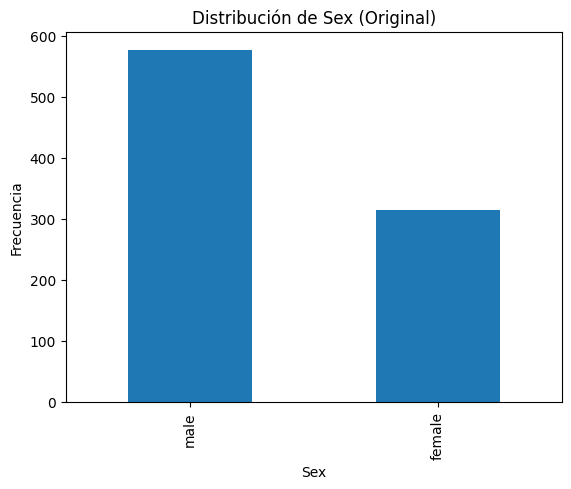

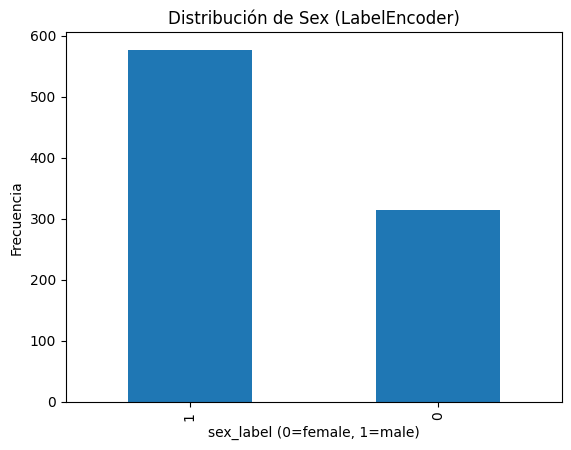

In [ ]:
data['sex'].value_counts().plot(kind='bar')
plt.title('Distribución de Sex (Original)')
plt.xlabel('Sex')
plt.ylabel('Frecuencia')
plt.show()

# Se puede ver que las frecuencias son iguales pero en la segunda grafica sus valores son numericos

data['sex_label'].value_counts().plot(kind='bar')
plt.title('Distribución de Sex (LabelEncoder)')
plt.xlabel('sex_label (0=female, 1=male)')
plt.ylabel('Frecuencia')
plt.show()



### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [16]:
# Codificación de la variable 'class' con LabelEncoder y OneHotEncoder
data['class_label'] = label_encoder.fit_transform(data['class'])
print(data[['class', 'class_label']].drop_duplicates())

onehot_encoder_class = pd.get_dummies(data['class'], prefix='class', dtype=int)
print(onehot_encoder_class.head())

    class  class_label
0   Third            2
1   First            0
9  Second            1
   class_First  class_Second  class_Third
0            0             0            1
1            1             0            0
2            0             0            1
3            1             0            0
4            0             0            1


Si vemos el primer set Third=2 y Second=1 la categoria 'class' conlleva una jerarquia que se rompe con LabelEncoder pero no sucede con OneHotEncoder asi que para 'class' el enfoque de OneHotEncoder si tiene una ventaja.

### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [ ]:
Para este set de datos

'sex' Es de tipo nominal no implica una jerarquia es mejor OneHotEncoder
'embarked' Es de tipo nominal no implica una jerarquia es mejor OneHotEncoder
'class' Es de tipo ordinal implica una jerarquia es mejor LabelEncoder pero hay que tener la precaucion 
        de que asigna el orden de forma alfabetica First = 0, Second = 1, Third = 2 es pura casualidad 
        en otros casos hay que aplicar un mapa ej.# Mapeas manualmente la jerarquía que tú deseas
         mapa_clases = {
                         'Third': 3,
                          'Second': 2,
                          'First': 1
                       }

         data['class_encoded'] = data['class'].map(mapa_clases) 

Asi que tratando de generalizar depende del tipo de variable y del contexto del problema, 
si es nominal o ordinal, si hay jerarquia o no, si es numerica o categorica.

